# MISO subregion load-forecast validation

Compare the archived direct MISO forecast and the sum of six subregion forecasts with
the same cleaned 2023 EIA-930 total-MISO actual load. These are separate model estimates,
not interchangeable region labels.

**Inputs:** Cleaned MISO actuals and seven historical forecast files.
**Outputs:** Inline coverage, a complete metric table, and a scatter plot; no standalone files.


## Setup

Run this notebook from `notebooks/validation`. No online acquisition is required.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

## Step 1: Read actual load and the direct MISO forecast

Both series are restricted to the 8,760 UTC hours of 2023 and must be unique by
timestamp.


In [2]:
YEAR = 2023
EXPECTED_HOURS = 8_760

actual = pd.read_csv(
    "../../data_inputs/load_actuals/cleaned_2023/MISO_cleaned_load_2023.csv",
    usecols=["time_utc", "load_actual_mw_clean"],
)
actual["time_utc"] = pd.to_datetime(actual["time_utc"], utc=True)
actual = actual.loc[actual["time_utc"].dt.year.eq(YEAR)].copy()

direct = pd.read_csv(
    "../../data_inputs/wtk_bchrrr_nsrdb_2007_2023/ba_load/MISO_wtk_bchrrr_nsrdb_2007_2023_load.csv",
    usecols=["time_utc", "load_mw"],
)
direct["time_utc"] = pd.to_datetime(direct["time_utc"], utc=True)
direct = direct.loc[direct["time_utc"].dt.year.eq(YEAR)].copy()
direct.rename(columns={"load_mw": "direct_forecast_mw"}, inplace=True)

for label, frame in [("actual", actual), ("direct forecast", direct)]:
    if len(frame) != EXPECTED_HOURS or frame["time_utc"].duplicated().any():
        raise AssertionError(f"The {label} series must contain 8,760 unique 2023 hours.")

print(f"Cleaned actual and direct MISO forecast each contain {EXPECTED_HOURS:,} unique {YEAR} UTC timestamps.")


Cleaned actual and direct MISO forecast each contain 8,760 unique 2023 UTC timestamps.


## Step 2: Sum the six MISO subregion forecasts

All six subregions are aligned by UTC timestamp before summation. `min_count=6`
prevents an incomplete hour from being treated as a valid MISO total.


In [3]:
MISO_SUBREGIONS = ["MISO_0001", "MISO_0004", "MISO_0006", "MISO_0027", "MISO_0035", "MISO_8910"]
subregion_series = []
subregion_rows = []

for subregion in MISO_SUBREGIONS:
    frame = pd.read_csv(
        f"../../data_inputs/wtk_bchrrr_nsrdb_2007_2023/ba_load/{subregion}_wtk_bchrrr_nsrdb_2007_2023_load.csv",
        usecols=["time_utc", "load_mw"],
    )
    frame["time_utc"] = pd.to_datetime(frame["time_utc"], utc=True)
    frame = frame.loc[frame["time_utc"].dt.year.eq(YEAR)].copy()
    if len(frame) != EXPECTED_HOURS or frame["time_utc"].duplicated().any():
        raise AssertionError(f"Incomplete or duplicate 2023 forecast hours for {subregion}.")

    series = frame.set_index("time_utc")["load_mw"].rename(subregion)
    subregion_series.append(series)
    subregion_rows.append({
        "subregion": subregion, "hours": len(series), "mean_forecast_mw": series.mean()
    })

subregions_wide = pd.concat(subregion_series, axis=1).sort_index()
if list(subregions_wide.columns) != MISO_SUBREGIONS or subregions_wide.isna().any().any():
    raise AssertionError("The six MISO subregion forecasts are not fully aligned.")

subregion_sum = subregions_wide.sum(axis=1, min_count=len(MISO_SUBREGIONS)).rename(
    "subregion_sum_forecast_mw"
)
display(
    pd.DataFrame(subregion_rows).rename(columns={
        "subregion": "Subregion", "hours": "Hours", "mean_forecast_mw": "Mean forecast (MW)"
    }).set_index("Subregion").round({"Mean forecast (MW)": 1})
)


,Hours,Mean forecast (MW)
Subregion,,
MISO_0001,8760,10470.5
MISO_0004,8760,5265.5
MISO_0006,8760,9797.8
MISO_0027,8760,17767.2
MISO_0035,8760,9914.6
MISO_8910,8760,19688.4


## Step 3: Build the common hourly comparison and calculate metrics

Forecast error is forecast minus cleaned actual load. Both forecast methods use
identical hours and the same actual-load denominator.

NRMSE is RMSE divided by mean actual load; MAPE is stored as a fraction and displayed as a percentage.


In [4]:
comparison = actual.merge(direct, on="time_utc", how="inner", validate="one_to_one")
comparison = comparison.merge(subregion_sum.reset_index(), on="time_utc", how="inner", validate="one_to_one")
if len(comparison) != EXPECTED_HOURS or comparison[
    ["load_actual_mw_clean", "direct_forecast_mw", "subregion_sum_forecast_mw"]
].isna().any().any():
    raise AssertionError("The MISO comparison must contain three complete, aligned 2023 series.")

actual_values = comparison["load_actual_mw_clean"]
nonzero = actual_values.ne(0)
metric_rows = []
for label, forecast_column in [
    ("Direct total MISO", "direct_forecast_mw"),
    ("Sum of six MISO subregions", "subregion_sum_forecast_mw"),
]:
    forecast_values = comparison[forecast_column]
    error = forecast_values - actual_values
    rmse = float(np.sqrt(np.mean(np.square(error))))
    metric_rows.append(
        {
            "forecast": label,
            "hours_compared": len(comparison),
            "mae_mw": float(error.abs().mean()),
            "rmse_mw": rmse,
            "nrmse_mean_actual": rmse / float(actual_values.mean()),
            "mape": float((error.loc[nonzero].abs() / actual_values.loc[nonzero].abs()).mean()),
            "r2": float(1.0 - np.square(error).sum() / np.square(actual_values - actual_values.mean()).sum()),
            "bias_mw": float(error.mean()),
        }
    )

metrics = pd.DataFrame(metric_rows)
if not np.isfinite(metrics.select_dtypes(include="number").to_numpy()).all():
    raise AssertionError("MISO validation metrics must all be finite.")
display(
    metrics.assign(mape=metrics["mape"] * 100).rename(columns={'forecast': 'Forecast',
     'hours_compared': 'Hours compared',
     'mae_mw': 'MAE (MW)',
     'rmse_mw': 'RMSE (MW)',
     'bias_mw': 'Bias (MW)',
     'nrmse_mean_actual': 'NRMSE (fraction)',
     'mape': 'MAPE (%)',
     'r2': 'R²'}).set_index('Forecast').round({'MAE (MW)': 1,
     'RMSE (MW)': 1,
     'Bias (MW)': 1,
     'NRMSE (fraction)': 3,
     'MAPE (%)': 2,
     'R²': 3})
)


,Hours compared,MAE (MW),RMSE (MW),NRMSE (fraction),MAPE (%),R²,Bias (MW)
Forecast,,,,,,,
Direct total MISO,8760,1475.6,1914.0,0.026,2.06,0.970,-320.4
Sum of six MISO subregions,8760,1182.6,1603.4,0.022,1.64,0.979,-265.8


## Step 4: Plot direct and summed-subregion forecasts

The shared one-to-one line makes the two forecast approaches directly comparable.


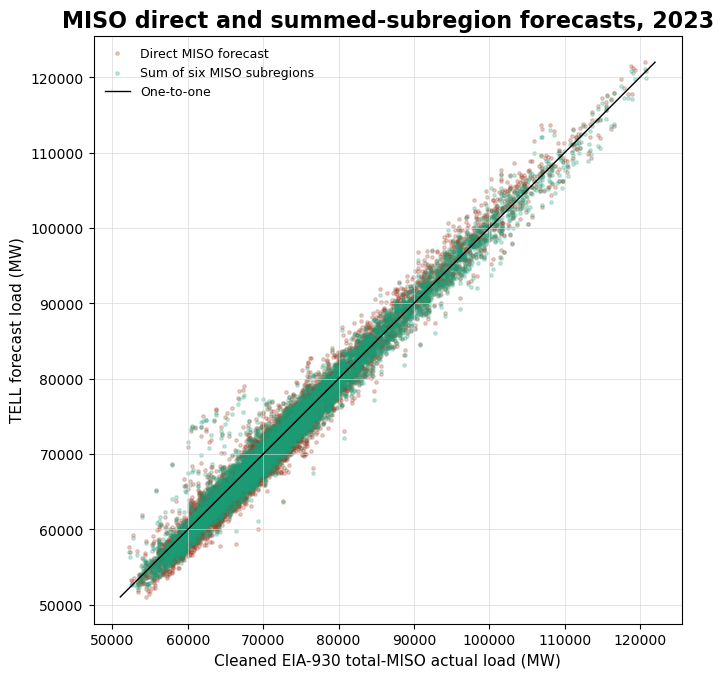

In [5]:
# Shared appearance for this notebook's figures.
plt.rcParams.update({
    "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "normal",
    "axes.labelsize": 11, "xtick.labelsize": 10, "ytick.labelsize": 10,
    "legend.fontsize": 9, "legend.frameon": False,
    "grid.color": "#d1d5db", "grid.linewidth": 0.7, "grid.alpha": 0.65,
    "figure.titlesize": 16, "figure.titleweight": "bold",
})

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(
    comparison["load_actual_mw_clean"],
    comparison["direct_forecast_mw"],
    s=6,
    alpha=0.24,
    color="#9f3a20",
    label="Direct MISO forecast",
    rasterized=True,
)
ax.scatter(
    comparison["load_actual_mw_clean"],
    comparison["subregion_sum_forecast_mw"],
    s=6,
    alpha=0.24,
    color="#1b9e77",
    label="Sum of six MISO subregions",
    rasterized=True,
)

limits = [
    comparison[["load_actual_mw_clean", "direct_forecast_mw", "subregion_sum_forecast_mw"]].min().min(),
    comparison[["load_actual_mw_clean", "direct_forecast_mw", "subregion_sum_forecast_mw"]].max().max(),
]
ax.plot(limits, limits, color="black", linewidth=1, label="One-to-one")
ax.set_xlabel("Cleaned EIA-930 total-MISO actual load (MW)")
ax.set_ylabel("TELL forecast load (MW)")
ax.set_title("MISO direct and summed-subregion forecasts, 2023", fontsize=16, fontweight="bold")
ax.set_aspect("equal", adjustable="box")
ax.grid(True)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


## Interpretation

On these common 2023 hours, the subregion sum has lower RMSE (about 1,603 MW)
than the direct MISO forecast (about 1,914 MW). This compares two load-modeling
approaches against the same observations; it does not measure a pooling benefit.
Both estimates retain their own roles in the later analyses.